# Minimizing Max/Min Distance Ratio (2D, n=16) — Analysis & Verification

This notebook verifies and visualizes solutions for the min-distance-ratio-2d problem.

**Problem:** Place 16 points in the 2D plane to minimize
$$R = \left(\frac{d_{\max}}{d_{\min}}\right)^2$$
where $d_{\max}$ and $d_{\min}$ are the maximum and minimum pairwise Euclidean distances. Lower $R$ is better.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Verification Function

The verifier computes:
1. All $\binom{16}{2} = 120$ pairwise Euclidean distances
2. $R = (d_{\max} / d_{\min})^2$

Points must be distinct (min distance $> 10^{-12}$).

In [2]:
def evaluate(data: dict) -> float:
    """Exact EinsteinArena verifier for min-distance-ratio-2d."""
    vectors = np.array(data["vectors"], dtype=np.float64)
    if vectors.ndim != 2 or vectors.shape[0] != 16 or vectors.shape[1] != 2:
        raise ValueError("Expected exactly 16 points in 2 dimensions, shape (16, 2)")
    n = vectors.shape[0]
    diff = vectors[:, None, :] - vectors[None, :, :]
    dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    pairwise = dist_matrix[mask]
    min_d = np.min(pairwise)
    if min_d < 1e-12:
        raise ValueError("Points must be distinct (min distance < 1e-12)")
    max_d = np.max(pairwise)
    return float((max_d / min_d) ** 2)

## 2. Load Solutions

In [3]:
with open('solutions/alphaevolve_2025.json') as fp:
    ae_data = json.load(fp)

with open('solutions/ours_2026.json') as fp:
    ours_data = json.load(fp)

solutions = [
    ("AlphaEvolve (2025)", ae_data),
    ("Together AI (2026)", ours_data),
]

for name, data in solutions:
    v = np.array(data["vectors"])
    print(f'{name}: 16 points, x range [{v[:, 0].min():.4f}, {v[:, 0].max():.4f}], y range [{v[:, 1].min():.4f}, {v[:, 1].max():.4f}]')

AlphaEvolve (2025): 16 points, x range [-0.8607, 0.9029], y range [-0.8907, 0.8552]
Together AI (2026): 16 points, x range [-1.8231, 1.7330], y range [-1.7898, 1.7989]


## 3. Verify Scores

In [4]:
print("=" * 70)
print("VERIFICATION OF ALL SOLUTIONS")
print("=" * 70)
print()

scores = {}
for name, data in solutions:
    score = evaluate(data)
    scores[name] = score
    print(f'{name}')
    print(f'  R = {score:.15f}')
    print()

print("=" * 70)
print("COMPARISON TABLE")
print("=" * 70)
print(f"{'Method':<25} {'R (lower is better)':>20}")
print("-" * 47)
for name, data in solutions:
    marker = "  <-- BEST" if scores[name] == min(scores.values()) else ""
    print(f"{name:<25} {scores[name]:>20.6f}{marker}")

VERIFICATION OF ALL SOLUTIONS

AlphaEvolve (2025)
  R = 12.889266112034630

Together AI (2026)
  R = 12.889229907717521

COMPARISON TABLE
Method                     R (lower is better)
-----------------------------------------------
AlphaEvolve (2025)                   12.889266
Together AI (2026)                   12.889230  <-- BEST


## 4. Visualization

Scatter plot of the 16-point configurations.

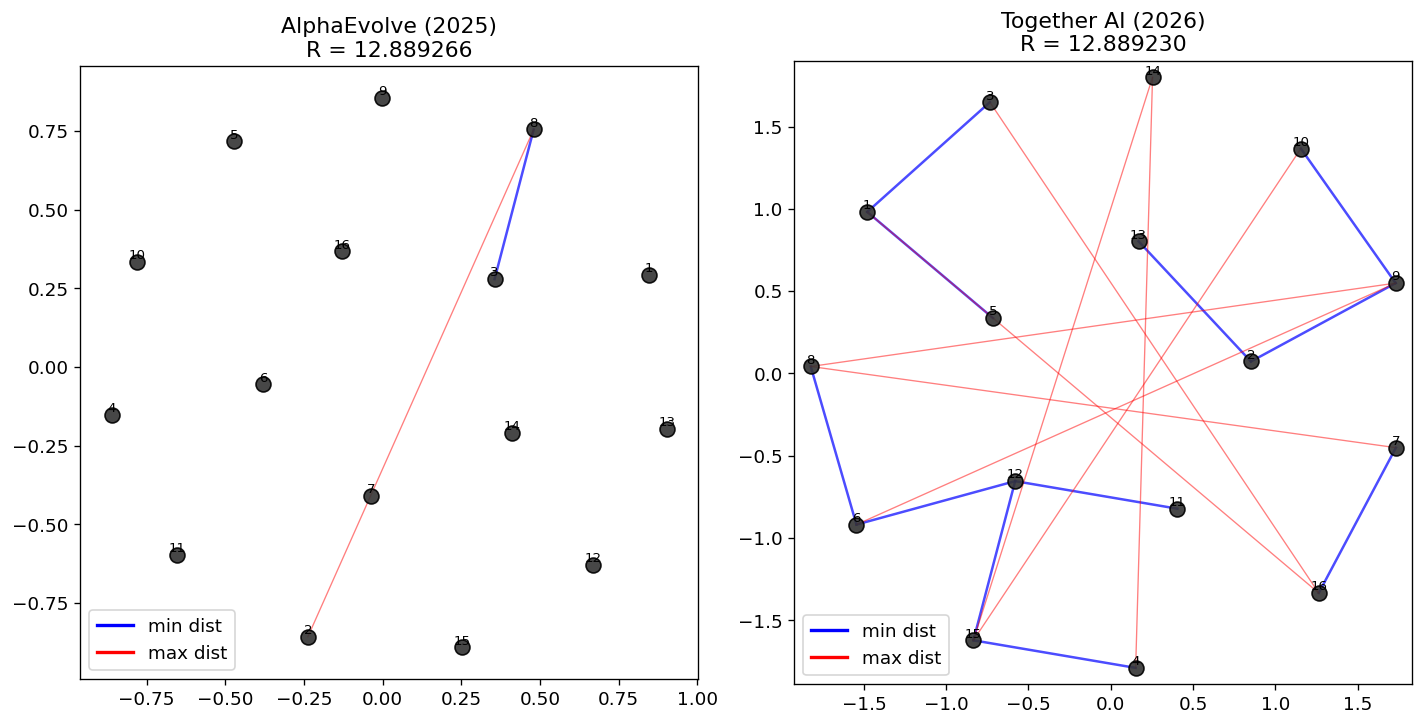

In [ ]:
def get_min_max_pairs(vectors):
    """Return (min_pairs, max_pairs) where each is a list of (i, j) indices."""
    v = np.array(vectors, dtype=np.float64)
    n = v.shape[0]
    diff = v[:, None, :] - v[None, :, :]
    dist = np.sqrt(np.sum(diff**2, axis=-1))
    min_d = np.min(dist[np.triu_indices(n, k=1)])
    max_d = np.max(dist[np.triu_indices(n, k=1)])
    min_pairs = [(i, j) for i in range(n) for j in range(i + 1, n) if abs(dist[i, j] - min_d) < 1e-12]
    max_pairs = [(i, j) for i in range(n) for j in range(i + 1, n) if abs(dist[i, j] - max_d) < 1e-12]
    return min_pairs, max_pairs

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, (name, data) in zip(axes, solutions):
    v = np.array(data["vectors"])
    min_pairs, max_pairs = get_min_max_pairs(v)

    # Draw min-distance edges (blue)
    for i, j in min_pairs:
        ax.plot([v[i, 0], v[j, 0]], [v[i, 1], v[j, 1]], 'b-', alpha=0.7, linewidth=1.5)
    # Draw max-distance edges (red)
    for i, j in max_pairs:
        ax.plot([v[i, 0], v[j, 0]], [v[i, 1], v[j, 1]], 'r-', alpha=0.5, linewidth=0.8)

    ax.scatter(v[:, 0], v[:, 1], s=80, alpha=0.9, c='#333333', edgecolors='black', linewidths=1, zorder=5)
    for i in range(16):
        ax.annotate(str(i + 1), (v[i, 0], v[i, 1]), fontsize=8, ha='center', va='bottom', zorder=6)
    ax.set_aspect('equal')
    ax.set_title(f'{name}\nR = {scores[name]:.6f}')
    ax.set_xlim(v[:, 0].min() - 0.1, v[:, 0].max() + 0.1)
    ax.set_ylim(v[:, 1].min() - 0.1, v[:, 1].max() + 0.1)
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([0], [0], color='b', linewidth=2, label='min dist'),
                       Line2D([0], [0], color='r', linewidth=2, label='max dist')], loc='lower left')

plt.tight_layout()
# plt.savefig('visual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()